Read in SDSS galaxy color data from solutions/galaxyquasar.csv. Create arrays for the  colors. Also create an array with the class labels where galaxy=0 and quasar=1.

Now we're going to fit a neural network classifier. First, scale your data appropriately and do a 30% train/test split.

Now train the classifier. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning.

Start from a network architecture with a single hidden layer with 5 neurons, using the adam solver, the relu activation function, and a learninig rate of 0.001. Plot the resulting ROC curve.

Now let's optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best. Do your best now to optimize the network architecture. Be creative!

Is your best result comparable with the simpler classifiers we've seen before? Do we need deep learning here? If yes, which features are captured best?

--- 

Let's start by preparing the dataset.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd

data = pd.read_csv('../solutions/galaxyquasar.csv')#, allow_pickle=True)
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder().fit(data['class'].to_numpy())
data['class'] = LE.transform(data['class'].to_numpy())# QSO = 1, Galaxy = 0

data['u-g'] = data['u']-data['g']
data['g-r'] = data['g']-data['r']
data['r-i'] = data['r']-data['i']
data['i-z'] = data['i']-data['z']

data = data[data['zerr']>0]
tData = data[['u-g', 'g-r', 'r-i', 'i-z', 'z1']]
yData = data['class']
del data

Let's import the necessary libraries and re-scale the dataset

In [19]:
import sklearn.model_selection
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

Scaler = StandardScaler()
xData = Scaler.fit_transform(tData)
xTrain, xTest, yTrain, yTest = sklearn.model_selection.train_test_split(xData[:1000], yData[:1000], test_size=0.33, random_state=42)

In [20]:
Network = sklearn.neural_network.MLPClassifier(
        hidden_layer_sizes=(5), 
        activation='relu',
        solver='adam',
        alpha=0,
        learning_rate_init=0.001,
        max_iter=200)

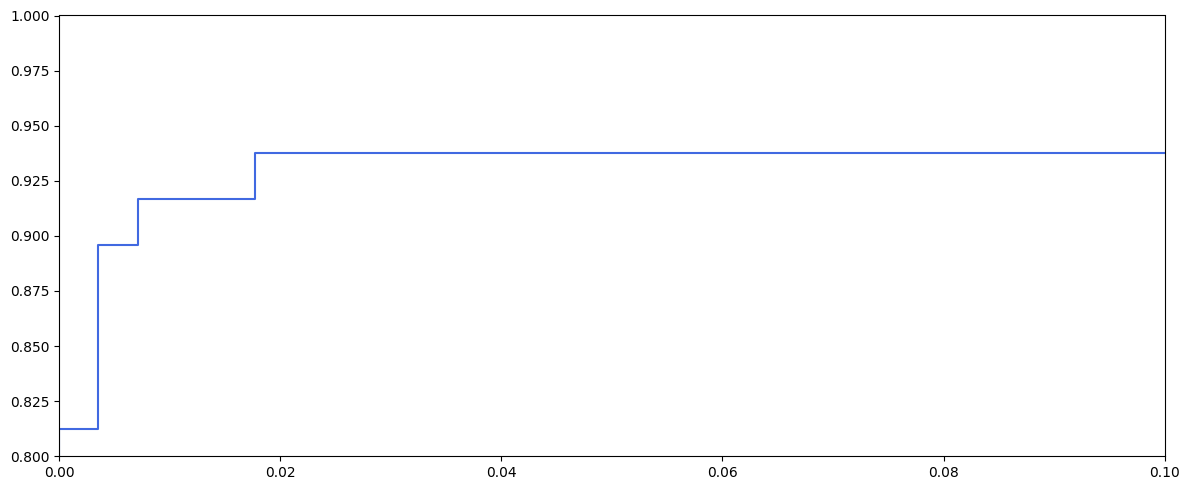

In [40]:
Network.fit(xTrain, yTrain)
yProb = Network.predict_proba(xTest)[:,1]

fpr, tpr, thresh = roc_curve(yTest, yProb)
plt.figure(figsize=(12,5), tight_layout=True)
plt.plot(fpr, tpr, c='royalblue')
_ = plt.xlim(0,0.1)
_ = plt.ylim(0.8,1)

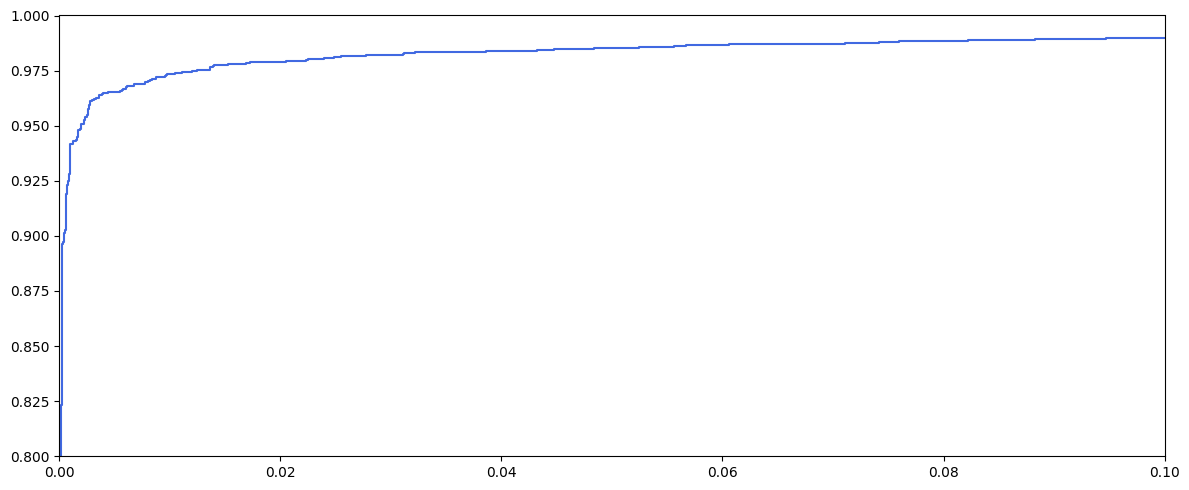

In [41]:
GS = GridSearchCV(estimator=Network, param_grid={'activation':['ReLU', 'logistic', 'tanh'],
                                                  'learning_rate_init':[0.1, 0.01, 0.03, 0.001],
                                                  })
import warnings
warnings.filterwarnings('ignore')
GS.fit(xTrain, yTrain)
BestNetwork = GS.best_estimator_
# apply on the full dataset
xTrain, xTest, yTrain, yTest = sklearn.model_selection.train_test_split(xData, yData, test_size=0.33, random_state=42)
BestNetwork.fit(xTrain, yTrain)
yProb = BestNetwork.predict_proba(xTest)[:,1]

fpr, tpr, thresh = roc_curve(yTest, yProb)
plt.figure(figsize=(12,5), tight_layout=True)
plt.plot(fpr, tpr, c='royalblue')
_ = plt.xlim(0,0.1)
_ = plt.ylim(0.8,1)

This is a very very naive application of a neural network, yet I see that there is a slight improvement in the performance by running a gridsearchCV on it. Do we need deep learning for this algorithm? I'm not sure: in fact, this is a relatively simple classification algorithm. By heart, I feel like it would be better to try and use a neural network on the GW exercise from a few lectures ago. In that case, the number of features is much larger.

Actually, the best application of a Neural network (even better: a CNN) would be on the handwritten digits exercise: in that case, the number of features is extremely high and it would be nice to check its performance vs. a tSNE or a "simple" classifier. 